# ANÁLISIS INICIAL DE FICHEROS Y PREPARACIÓN DEL CASO

Usaremos datos reales ofrecidos por AirBnB en esta página: http://insideairbnb.com/get-the-data.html

Concretamente usaremos la ciudad de Madrid, pero en la página tienes muchas más ciudades por si tienes interés en replicarlo con una localización más significativa para ti.

Como ves AirBnb entrega los datos en formato csv y con todo en inglés.

A efectos de este programa y de cara a tu aprendizaje yo voy a hacer modificaciones para:

* Quedarnos sólo con las tablas que nos vayan a resultar útiles
* Cargar toda la info a una base de datos para practicar con este formato, ya que será el más habitual en entornos empresariales

Podría haber hecho todo esto "en cocina" y empezar el ejercicio ya con ese formato, pero creo que esta primera parte "detrás de las cámaras" también puede tener aprendizajes para ti, así que la he incluído también como parte del contenido formativo.

## SETUP

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#Automcompletar rápido
%config IPCompleter.greedy=True

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 400)


## ENTENDER LOS FICHEROS

En la web de AirBnB podemos ver la descripción de las tablas:

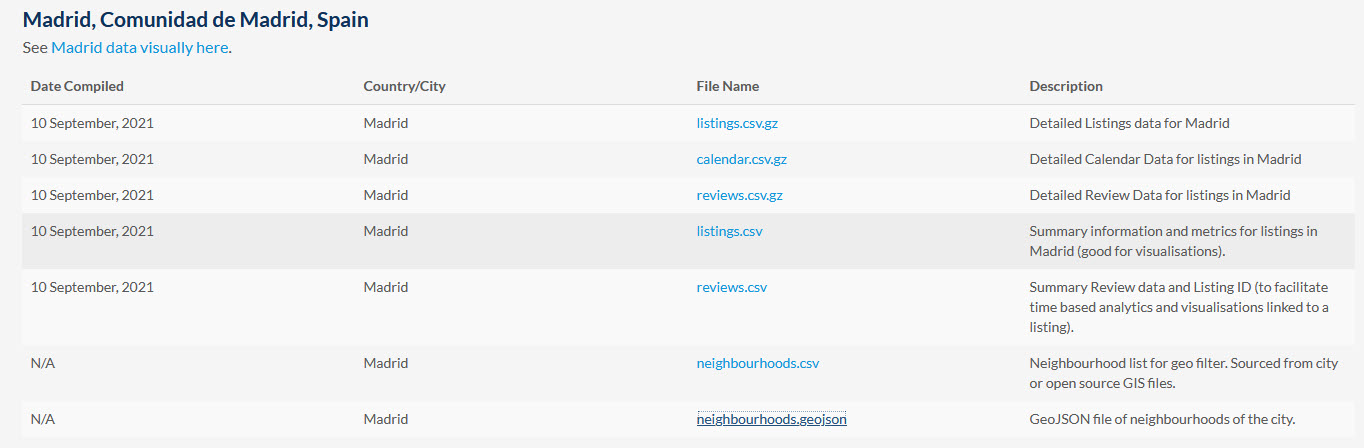

In [32]:
from IPython import display
display.Image("../../../99_Media/airbnb_ficheros.jpg")

Vamos a cargar una por una, entenderlas y tomar decisión de si la usamos o no.

### Cargamos y entendemos listings agregados

In [3]:
listings = pd.read_csv('../Datos/listings.csv')

In [7]:
listings.head(400)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.403810,-3.741300,Private room,31.0,4,33,2018-07-15,0.27,2,144,0,NaN
1,30320,Great Vacational Apartments,130907,Dana,Centro,Sol,40.414760,-3.704180,Entire home/apt,NaN,5,172,2022-09-26,0.98,3,0,0,NaN
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.412590,-3.701050,Entire home/apt,NaN,3,8,2017-05-30,0.07,1,0,0,NaN
3,40916,Holiday Apartment Madrid Center,130907,Dana,Centro,Universidad,40.422470,-3.705770,Entire home/apt,NaN,5,49,2021-12-11,0.29,3,0,0,NaN
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,303845,Arturo,Centro,Justicia,40.418840,-3.696550,Private room,69.0,1,219,2024-11-24,2.73,3,332,44,NaN
5,70059,Tu hogar en centro de Madrid.,353616,Diana,Centro,Universidad,40.423810,-3.710380,Entire home/apt,NaN,15,61,2022-12-19,0.36,1,0,0,VT-7440
6,70073,Adorable Apartment Malasaña-Gran Via,353738,Raquel,Centro,Universidad,40.422520,-3.702500,Entire home/apt,80.0,28,35,2024-06-20,0.22,4,273,3,NaN
7,70310,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",353738,Raquel,Centro,Universidad,40.422520,-3.702500,Entire home/apt,64.0,30,29,2023-11-18,0.17,4,299,0,NaN
8,72150,Sunny attic duplex flat with terrace next to Sol,364585,Vin,Centro,Embajadores,40.411500,-3.704490,Entire home/apt,159.0,3,121,2024-12-09,0.72,4,180,13,VT-6993
9,82481,"Retiro Park, Stay at cosy studio",448981,Mercedes,Salamanca,Recoletos,40.423420,-3.681230,Entire home/apt,NaN,3,105,2017-11-29,0.63,1,0,0,NaN


In [35]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26760 entries, 0 to 26759
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              26760 non-null  int64  
 1   name                            26760 non-null  object 
 2   host_id                         26760 non-null  int64  
 3   host_name                       26757 non-null  object 
 4   neighbourhood_group             26760 non-null  object 
 5   neighbourhood                   26760 non-null  object 
 6   latitude                        26760 non-null  float64
 7   longitude                       26760 non-null  float64
 8   room_type                       26760 non-null  object 
 9   price                           20815 non-null  float64
 10  minimum_nights                  26760 non-null  int64  
 11  number_of_reviews               26760 non-null  int64  
 12  last_review                     

### Cargamos y entendemos listings detalle

In [36]:
listings_det = pd.read_csv('../Datos/listings.csv.gz',compression='gzip')

In [37]:
listings_det.sort_values('last_scraped', ascending=True).head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20241212051353,2024-12-12,city scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,https://www.airbnb.com/users/show/83531,Abdel,2010-02-21,"Madrid, Spain",EN-ES-FR\r\nEN\r\nHi everybody: I'm Abdel. I'm...,NaN,NaN,0%,f,https://a0.muscache.com/im/users/83531/profile...,https://a0.muscache.com/im/users/83531/profile...,Aluche,2.0,2.0,"['email', 'phone']",t,t,"Madrid, Spain",Cármenes,Latina,40.403810,-3.741300,Private room in rental unit,Private room,1,1.0,1 bath,1.0,1.0,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",$31.00,4,40,4,4,40,40,4.0,40.0,NaN,t,0,0,0,144,2024-12-12,33,0,0,2014-10-10,2018-07-15,4.58,4.72,4.56,4.75,4.82,4.21,4.67,NaN,f,2,0,2,0,0.27
17845,1003629395376685756,https://www.airbnb.com/rooms/1003629395376685756,20241212051353,2024-12-12,city scrape,Cozy bedroom Apart AirPort/ IFEMA/ Stadium,"🏣Magnificent 132m2 apartment, with seven bedro...","t is a very well connected neighborhood, you w...",https://a0.muscache.com/pictures/hosting/Hosti...,2536524,https://www.airbnb.com/users/show/2536524,Danna Elizabeth,2012-06-03,"Madrid, Spain",Somos Marina & Elizabeth y te damos la bienven...,within an hour,100%,100%,NaN,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,San Blas,10.0,10.0,"['email', 'phone']",t,t,"Madrid, Comunidad de Madrid, Spain",Arcos,San Blas - Canillejas,40.426699,-3.616304,Private room,Private room,2,2.0,2 baths,1.0,1.0,"[""Board games"", ""Books and reading material"", ...",$35.00,28,720,1,28,1125,1125,27.3,1125.0,NaN,t,23,50,50,178,2024-12-12,31,31,0,2024-01-02,2024-08-04,4.32,4.39,4.32,4.65,4.74,3.65,4.03,NaN,t,6,0,6,0,2.69
17844,1003544416200208652,https://www.airbnb.com/rooms/1003544416200208652,20241212051353,2024-12-12,city scrape,Habitación privada-MetroHortaleza/Aeropuerto/I...,"Comfortable room and spacious, just a 3 minute...","It's a residential area, close to supermarkets...",https://a0.muscache.com/pictures/hosting/Hosti...,266592715,https://www.airbnb.com/users/show/266592715,Felipe,2019-06-05,"Madrid, Spain",NaN,within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User-...,https://a0.muscache.com/im/pictures/user/User-...,NaN,3.0,7.0,"['email', 'phone']",t,t,"Madrid, Comunidad de Madrid, Spain",Pinar del Rey,Hortaleza,40.473540,-3.655590,Private room in rental unit,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Wifi"", ""Central air conditioning"", ""Kitchen""...",$30.00,1,365,1,1,365,365,1.0,365.0,NaN,t,13,36,66,135,2024-12-12,106,95,2,202

In [38]:
listings_det.sort_values('last_scraped', ascending=False).head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20241212051353,2024-12-12,city scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,https://www.airbnb.com/users/show/83531,Abdel,2010-02-21,"Madrid, Spain",EN-ES-FR\r\nEN\r\nHi everybody: I'm Abdel. I'm...,NaN,NaN,0%,f,https://a0.muscache.com/im/users/83531/profile...,https://a0.muscache.com/im/users/83531/profile...,Aluche,2.0,2.0,"['email', 'phone']",t,t,"Madrid, Spain",Cármenes,Latina,40.403810,-3.741300,Private room in rental unit,Private room,1,1.0,1 bath,1.0,1.0,"[""First aid kit"", ""Wifi"", ""Kitchen"", ""Essentia...",$31.00,4,40,4,4,40,40,4.0,40.0,NaN,t,0,0,0,144,2024-12-12,33,0,0,2014-10-10,2018-07-15,4.58,4.72,4.56,4.75,4.82,4.21,4.67,NaN,f,2,0,2,0,0.27
17874,1006324056864682114,https://www.airbnb.com/rooms/1006324056864682114,20241212051353,2024-12-12,city scrape,Argento - 3 bedrooms in Almagro,Our mission is to empower individuals to immer...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,346367515,https://www.airbnb.com/users/show/346367515,Ukio,2020-05-15,"Barcelona, Spain",Ukio's mission is to empower individuals to li...,within an hour,96%,97%,f,https://a0.muscache.com/im/pictures/user/f790e...,https://a0.muscache.com/im/pictures/user/f790e...,Ibiza,802.0,814.0,"['phone', 'work_email']",t,t,NaN,Almagro,Chamberí,40.431620,-3.692560,Entire rental unit,Entire home/apt,6,2.0,2 baths,3.0,4.0,"[""Wifi"", ""Kitchen"", ""Essentials"", ""Stove"", ""Ho...",$119.00,31,330,31,31,330,330,31.0,330.0,NaN,t,0,0,0,158,2024-12-12,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,332,332,0,0,NaN
17846,1003740172087771212,https://www.airbnb.com/rooms/1003740172087771212,20241212051353,2024-12-12,city scrape,BNBHolder Boutique SOL III,Designer and high quality hostel formed by fiv...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,430251460,https://www.airbnb.com/users/show/430251460,Emilio,2021-11-03,NaN,NaN,within an hour,100%,99%,NaN,https://a0.muscache.com/im/pictures/user/c168e...,https://a0.muscache.com/im/pictures/user/c168e...,NaN,4.0,5.0,"['email', 'phone']",t,t,NaN,Cortes,Centro,40.418370,-3.699168,Private room in rental unit,Private room,2,1.0,1 private bath,1.0,1.0,"[""Wifi"", ""Essentials"", ""Smart lock"", ""Hot wate...",$117.00,1,1125,1,2,1125,1125,1.3,1125.0,NaN,t,21,50,80,351,2024-12-12,9,8,1,2023-10-22,2024-11-22,4.89,4.78,4.78,4.33,4.33,5.00,4.67,NaN,t,1,0,1,0,0.65
17845,1003629395376685756,https://www.airbnb.com/rooms/1003629395376685756,20241212051353,2024-12-12,city scrape,Cozy bedroom Apart AirPort/ IFEMA/ Stadium,"🏣Magnificen

In [39]:
listings_det.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26760 entries, 0 to 26759
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            26760 non-null  int64  
 1   listing_url                                   26760 non-null  object 
 2   scrape_id                                     26760 non-null  int64  
 3   last_scraped                                  26760 non-null  object 
 4   source                                        26760 non-null  object 
 5   name                                          26760 non-null  object 
 6   description                                   25740 non-null  object 
 7   neighborhood_overview                         12228 non-null  object 
 8   picture_url                                   26759 non-null  object 
 9   host_id                                       26760 non-null 

Conclusiones: 

* Son los mismos registros pero el fichero de detalle tiene más columnas.
* Podríamos unirlas mediante el campo id

### Cargamos y entendemos reviews agregado

In [40]:
reviews = pd.read_csv('../Datos/reviews.csv')

In [41]:
reviews

,listing_id,date
0,21853,2014-10-10
1,21853,2014-10-13
2,21853,2014-11-09
3,21853,2014-11-11
4,21853,2014-11-16
...,...,...
1257281,1305107967184386769,2024-12-08
1257282,1305641953387337626,2024-12-11
1257283,1305648081330896331,2024-12-08
1257284,1305770927805000044,2024-12-08


In [42]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257286 entries, 0 to 1257285
Data columns (total 2 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   listing_id  1257286 non-null  int64 
 1   date        1257286 non-null  object
dtypes: int64(1), object(1)
memory usage: 19.2+ MB


### Cargamos y entendemos reviews detalle

In [43]:
reviews_det = pd.read_csv('../Datos/reviews.csv.gz',compression = 'gzip')

In [44]:
reviews_det.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,21853,21051116,2014-10-10,8506071,Pedro Abel,"Mi experiencia en casa de Adel fue buena, aunq..."
1,21853,21268157,2014-10-13,19062863,Olga,Adel is a very warm person and thoughtful! He...
2,21853,22527396,2014-11-09,6099461,Hugh,Adel is an exceptionally welcoming host. I was...
3,21853,22684525,2014-11-11,23357657,Sendy,"Adel fue muy amable, incluso el día de mi lleg..."
4,21853,22871843,2014-11-16,4072731,Nati,Abdel ha sido un magnífico anfitrión y la mejo...


In [45]:
reviews_det

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,21853,21051116,2014-10-10,8506071,Pedro Abel,"Mi experiencia en casa de Adel fue buena, aunq..."
1,21853,21268157,2014-10-13,19062863,Olga,Adel is a very warm person and thoughtful! He...
2,21853,22527396,2014-11-09,6099461,Hugh,Adel is an exceptionally welcoming host. I was...
3,21853,22684525,2014-11-11,23357657,Sendy,"Adel fue muy amable, incluso el día de mi lleg..."
4,21853,22871843,2014-11-16,4072731,Nati,Abdel ha sido un magnífico anfitrión y la mejo...
...,...,...,...,...,...,...
1257281,1305107967184386769,1307185703641228415,2024-12-08,559331272,Diego,El local está muy bien cuidado y reservado. El...
1257282,1305641953387337626,1309314994816702790,2024-12-11,666115988,Jason Kingsley,"What a nice, spacious and cozy place! Thank yo..."
1257283,1305648081330896331,1307325460428639575,2024-12-08,590108200,대규,최악입니다 변호사라고 등록된 호스트는 결제를 바로 하면 언제든지 체크인 된다고 하였...
1257284,1305770927805000044,1307140021782060977,2024-12-08,665719033,Karina,Value/price is incomparable. Thank you for eve...


Conclusiones: 

* Son los mismos registros pero el fichero de detalle tiene más columnas.
* Realmente esta info de las reseñas no nos aporta nada a nuestro objetivo, así que no usaremos estas tablas

### Cargamos y entendemos calendar

In [48]:
calendar = pd.read_csv('../Datos/calendar.csv.gz',compression = 'gzip')

In [51]:
calendar.head(400)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,21853,2024-12-12,f,$30.00,NaN,4,40
1,21853,2024-12-13,f,$30.00,NaN,4,40
2,21853,2024-12-14,f,$30.00,NaN,4,40
3,21853,2024-12-15,f,$30.00,NaN,4,40
4,21853,2024-12-16,f,$30.00,NaN,4,40
5,21853,2024-12-17,f,$30.00,NaN,4,40
6,21853,2024-12-18,f,$30.00,NaN,4,40
7,21853,2024-12-19,f,$30.00,NaN,4,40
8,21853,2024-12-20,f,$30.00,NaN,4,40
9,21853,2024-12-21,f,$30.00,NaN,4,40


In [52]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9767270 entries, 0 to 9767269
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  float64
 5   minimum_nights  int64  
 6   maximum_nights  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 521.6+ MB


Conclusiones:

* Esta tabla se proyecta hacia el futuro, y parece contener la disponibilidad de reservas
* No es información que nos sirva a nuestros fines y por tanto no la usaremos

### Cargamos y entendemos neighbourhoods.csv

In [53]:
neigh = pd.read_csv('../Datos/neighbourhoods.csv')

In [58]:
neigh.head(400)

,neighbourhood_group,neighbourhood
0,Arganzuela,Acacias
1,Arganzuela,Atocha
2,Arganzuela,Chopera
3,Arganzuela,Delicias
4,Arganzuela,Imperial
5,Arganzuela,Legazpi
6,Arganzuela,Palos de Moguer
7,Barajas,Aeropuerto
8,Barajas,Alameda de Osuna
9,Barajas,Casco Histórico de Barajas


Conclusiones:

* Es simplemente un maestro de vecindario y grupo de vecindario
* En principio no la usaremos, ya que tanto el vecindario como su grupo ya están incorporados en otras tablas

### Cargamos y entendemos neighbourhoods.geojson

In [55]:
neigh_geo = pd.read_json('../Datos/neighbourhoods.geojson')

In [56]:
neigh_geo.head(5)

,type,features
0,FeatureCollection,"{'type': 'Feature', 'geometry': {'type': 'Mult..."
1,FeatureCollection,"{'type': 'Feature', 'geometry': {'type': 'Mult..."
2,FeatureCollection,"{'type': 'Feature', 'geometry': {'type': 'Mult..."
3,FeatureCollection,"{'type': 'Feature', 'geometry': {'type': 'Mult..."
4,FeatureCollection,"{'type': 'Feature', 'geometry': {'type': 'Mult..."


In [57]:
neigh_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   type      128 non-null    object
 1   features  128 non-null    object
dtypes: object(2)
memory usage: 2.1+ KB


Conclusiones:

* Parece info de geometría para mapas
* Hacer mapas con geometrías se sale del alcance de este programa, veremos otra opción mucho más sencilla, así que no la usaremos

### Conclusiones del análisis de ficheros

* Tablas principales que usaremos:
    * listings.csv
    * listings.csv.gz

## CREACIÓN DE UNA BASE DE DATOS

Vamos a meter las tablas seleccionadas en una base de datos, con el objetivo que  vayas cogiendo soltura con este formato.

Usaremos la que es posiblemente la base de datos más sencilla: sqlite, ya que es auto-contenida, sin servidor y sin configuración, por lo que suele ser el formato elegido para almacenar proyectos "propios".

Además viene por defecto con Python 3 y se puede usar sin tener que instalar nada adicional.

Lectura recomendada para entender mejor los pros y contras de Sqlite: https://www.hostgator.mx/blog/sqlite-que-es-y-diferencias-con-mysql/

Para crear una base de datos con sqlite y cargar tablas simplemente tenemos que:

1. Crear una conexión como ya sabemos
2. Guardar los datos con to_sql, y si la tabla de destino no existe todavía la creará

Nota: si la tabla ya existiera y lo que queremos hacer es reemplazarla hay que usar el parámetro if_exists = 'replace'

Creamos la conexión:

In [59]:
import sqlalchemy as sa

con = sa.create_engine('sqlite:///../Datos/airbnb2025.db')

Creamos las tablas y cargamos los datos

In [60]:
listings.to_sql('listings', con = con, if_exists = 'replace')
listings_det.to_sql('listings_det', con = con, if_exists = 'replace')
calendar.to_sql('calendar', con = con, if_exists = 'replace')
neigh.to_sql('neigh', con = con, if_exists = 'replace')

128